In [1]:
# This Python 3 environment comes with many helpfzul analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/"directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv
/kaggle/input/crime-cast-forecasting-crime-categories/train.csv
/kaggle/input/crime-cast-forecasting-crime-categories/test.csv


# Data Loading and Preprocessing

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xgboost as xgb
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder,StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

> Loading the dataset

In [3]:
train_data = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
test_data = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")

In [4]:
test_data

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,1500 LEIGHTON AV,NaN,34.0128,-118.3045,03/03/2020 12:00:00 AM,03/03/2020 12:00:00 AM,2000.0,3.0,Southwest,376.0,...,0416 1241 1243 1813 1821 2000,28.0,F,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont
1,100 S NORMANDIE AV,NaN,34.0726,-118.3029,06/01/2020 12:00:00 AM,04/25/2020 12:00:00 AM,1700.0,20.0,Olympic,2014.0,...,0344 0394,26.0,M,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont
2,300 E 111TH ST,NaN,33.9348,-118.2695,08/28/2020 12:00:00 AM,08/27/2020 12:00:00 AM,900.0,18.0,Southeast,1844.0,...,1822 0701 1914 0355 1202 0100,62.0,F,B,721.0,HIGH SCHOOL,NaN,NaN,IC,Invest Cont
3,1300 S LA BREA AV,NaN,34.0497,-118.3442,12/23/2020 12:00:00 AM,12/03/2020 12:00:00 AM,2200.0,7.0,Wilshire,765.0,...,NaN,0.0,NaN,NaN,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont
4,11000 MORRISON ST,NaN,34.1611,-118.3704,08/30/2020 12:00:00 AM,08/29/2020 12:00:00 AM,130.0,15.0,N Hollywood,1555.0,...,1501,37.0,F,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,AO,Adult Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4600 MASCOT ST,NaN,34.0409,-118.3408,06/05/2020 12:00:00 AM,06/04/2020 12:00:00 AM,2100.0,7.0,Wilshire,775.0,...,NaN,0.0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont
4996,2200 E 7TH ST,NaN,34.0347,-118.2253,12/02/2020 12:00:00 AM,11/25/2020 12:00:00 AM,1530.0,4.0,Hollenbeck,471.0,...,1300 0325,0.0,X,X,116.0,OTHER/OUTSIDE,NaN,NaN,IC,Invest Cont
4997,LANGDON AV,TUPPER ST,34.2392,-118.4698,11/21/2020 12:00:00 AM,11/21/2020 12:00:00 AM,2100.0,19.0,Mission,1961.0,...,0913 1817 0416,38.0,M,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest
4998,400 E 5TH ST,NaN,34.0453,-118.2443,03/01/2020 12:00:00 AM,02/29/2020 12:00:00 AM,2335.0,1.0,Central,147.0,...,0416,41.0,M,B,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other


In [5]:
train_data

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5100 W ADAMS BL,NaN,34.0334,-118.3523,05/24/2020 12:00:00 AM,05/24/2020 12:00:00 AM,700.0,3.0,Southwest,303.0,...,51.0,M,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Violent Crimes
19996,16900 ROSCOE BL,NaN,34.2212,-118.5011,12/25/2020 12:00:00 AM,12/25/2020 12:00:00 AM,259.0,10.0,West Valley,1008.0,...,0.0,M,W,301.0,GAS STATION,NaN,NaN,IC,Invest Cont,Property Crimes
19997,1000 S SHENANDOAH ST,NaN,34.0571,-118.3815,09/25/2020 12:00:00 AM,09/25/2020 12:00:00 AM,1400.0,8.0,West LA,849.0,...,42.0,M,H,102.0,SIDEWALK,NaN,NaN,IC,Invest Cont,Property Crimes
19998,300 W SEPULVEDA ST,NaN,33.7451,-118.2835,06/10/2020 12:00:00 AM,06/10/2020 12:00:00 AM,600.0,5.0,Harbor,558.0,...,76.0,F,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Crimes against Public Order


# Visualisation

> The below code creates histogram for each numerical column in train_data to visualize data distributions, using 100 bins with blue edges. It sets the figure size to 16x10 inches and adjusts spacing between plots to prevent overlap, then displays the histograms to help identify patterns or anomalies.

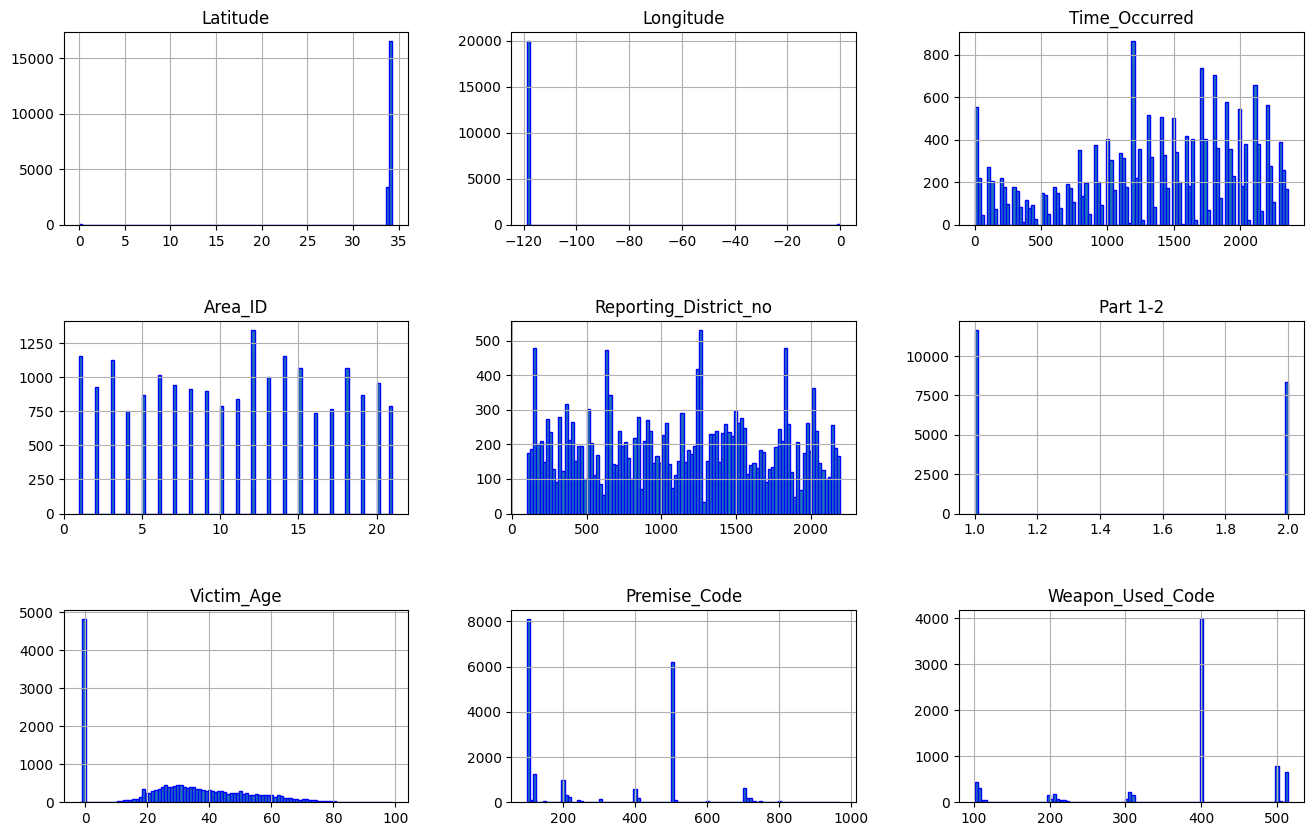

In [6]:
train_data.hist(bins=100, edgecolor='blue', figsize=(16, 10))# Create histograms for each numerical column in the train_data DataFrame.
plt.subplots_adjust(hspace=0.5, wspace=0.3) # Adjust the spacing between the plots to make them more readable.
plt.show() #Display the plots

Summary Statistics:
       Location Cross_Street      Latitude     Longitude  \
count     20000         3448  20000.000000  20000.000000   
unique    12399         1495           NaN           NaN   
top         6TH     BROADWAY           NaN           NaN   
freq         33           56           NaN           NaN   
mean        NaN          NaN     33.940704   -117.893072   
std         NaN          NaN      2.126810      7.377726   
min         NaN          NaN      0.000000   -118.663400   
25%         NaN          NaN     34.009200   -118.429700   
50%         NaN          NaN     34.058700   -118.323000   
75%         NaN          NaN     34.165025   -118.274400   
max         NaN          NaN     34.328100      0.000000   

                 Date_Reported           Date_Occurred  Time_Occurred  \
count                    20000                   20000   20000.000000   
unique                     811                     366            NaN   
top     07/13/2020 12:00:00 AM  01/01/20

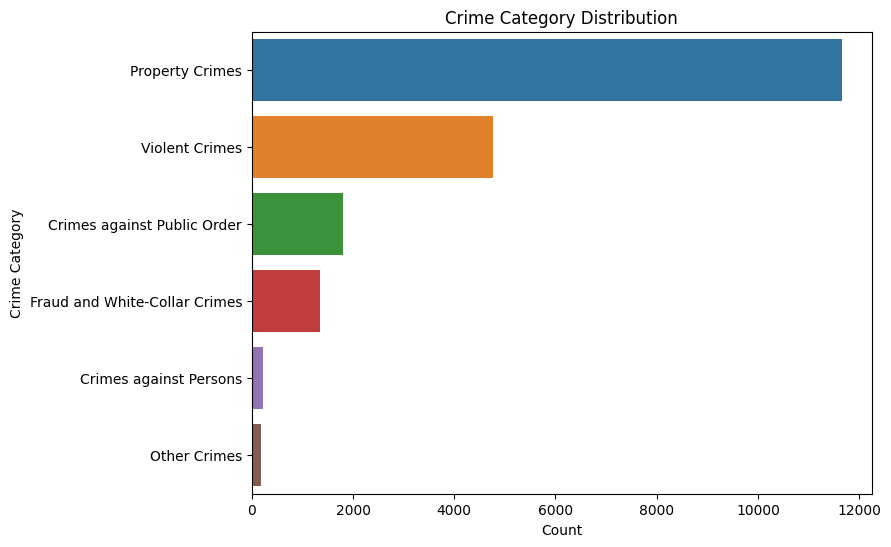

In [7]:
# Highlight Important Insights or Findings from the Dataset

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming train_data is your DataFrame and 'Crime_Category' is the target column
y = train_data['Crime_Category']

# Displaying summary statistics
print("Summary Statistics:")
print(train_data.describe(include='all'))

# Analyzing class distribution of target variable
plt.figure(figsize=(8, 6))
sns.countplot(data=train_data, y='Crime_Category', order=y.value_counts().index)
plt.title('Crime Category Distribution')
plt.xlabel('Count')
plt.ylabel('Crime Category')
plt.show()

# Detecting missing data

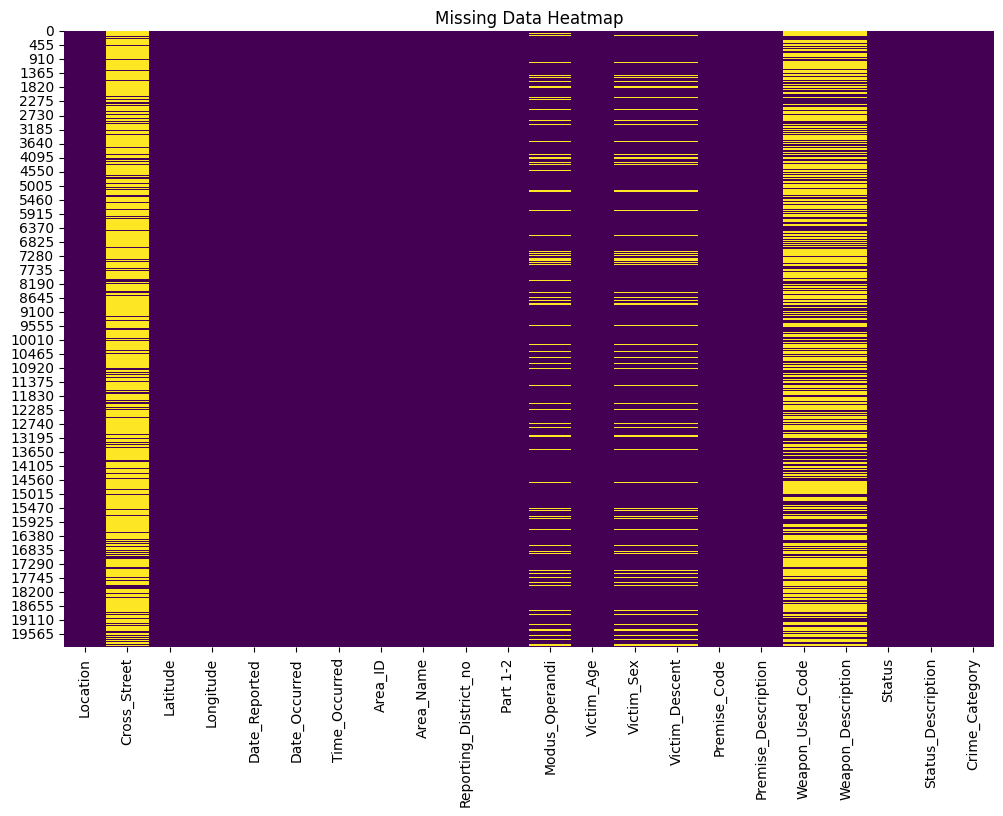

In [8]:
# Visualize missing data
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [9]:
# Count missing values in each column
missing_values = train_data.isnull().sum()
print(f"Missing Values in Each Column:\n{missing_values[missing_values > 0]}")

Missing Values in Each Column:
Cross_Street           16552
Modus_Operandi          2741
Victim_Sex              2624
Victim_Descent          2624
Premise_Description        5
Weapon_Used_Code       12665
Weapon_Description     12665
dtype: int64


# Separating Features and Target Variables

> The below code separates the features and target variable from the train_data DataFrame to prepare for machine learning. It assigns all columns except Crime_Category to X, representing the input features, and extracts the Crime_Category column into y, representing the labels the model will learn to predict. This separation is a standard step before training a model.

In [10]:
X = train_data.drop(columns=['Crime_Category'])# Create a DataFrame 'X' with all features by removing the target column 'Crime_Category' from 'train_data'.
y = train_data['Crime_Category'] # Extract the target variable 'Crime_Category' from 'train_data' and store it in 'y'.

# Encoding and Decoding Categorical Variables

In [11]:
X_copy = X.copy() #creating copy of input dataframe to avoid modifying the original data
le = LabelEncoder() #initialising label encoder instance

# Encoding categorical variables
X_copy['Cross_Street_Encoded'] = le.fit_transform(X_copy['Cross_Street'].astype(str)) # Encode 'Cross_Street' as numerical values for processing
X_copy['Location_Encoded'] = le.fit_transform(X_copy['Location'].astype(str)) # Encode "Location" as numerical values for processing

# Imputation of Missing Values using KNNImputer

In [12]:
# Preparing data for imputation
impute_columns = ['Location_Encoded', 'Cross_Street_Encoded', 'Latitude', 'Longitude'] 
imputed_df = X_copy[impute_columns] # Extract columns into a new DataFrame for imputation

# Imputing missing values using KNNImputer
imputer = KNNImputer(n_neighbors=3) # Initialize KNNImputer with 3 neighbors to fill missing values
imputed_array = imputer.fit_transform(imputed_df) # Fit the imputer and transform the selected columns, replacing missing values
imputed_data = pd.DataFrame(imputed_array, columns=impute_columns) # Convert the imputed array back into a DataFrame with the same column names

# Decoding the encoded Categorical Variables

In [13]:
# Decoding the encoded categorical variables
imputed_data['Cross_Street'] = le.inverse_transform(imputed_data['Cross_Street_Encoded'].round().astype(int)) # Decode 'Cross_Street_Encoded' back to original categorical values
imputed_data['Location'] = le.inverse_transform(imputed_data['Location_Encoded'].round().astype(int)) # Decode 'Location_Encoded' back to original categorical values

# Dropping encoded columns
imputed_data.drop(columns=['Location_Encoded', 'Cross_Street_Encoded'], inplace=True)

# Summary of Imputed Dataframe

In [14]:
imputed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Latitude      20000 non-null  float64
 1   Longitude     20000 non-null  float64
 2   Cross_Street  20000 non-null  object 
 3   Location      20000 non-null  object 
dtypes: float64(2), object(2)
memory usage: 625.1+ KB


# Imputing Missing Values for "Cross_Street" feature

In [15]:
X.loc[:, 'Cross_Street'] = imputed_data['Cross_Street']

# Test data copy and Label Encoding

In [16]:
# Create a copy of the test data
test_data_copy = test_data.copy()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode 'Cross_Street' and 'Location' columns
test_data_copy['Cross_Street_Encoded'] = label_encoder.fit_transform(test_data_copy['Cross_Street'].astype(str))
test_data_copy['Location_Encoded'] = label_encoder.fit_transform(test_data_copy['Location'].astype(str))

# Columns for Imputation

In [17]:
# Select columns for imputation
columns_for_imputation = ['Location_Encoded', 'Cross_Street_Encoded', 'Latitude', 'Longitude']
data_to_impute = test_data_copy[columns_for_imputation]

# Imputing Missing Values

In [18]:
# Initialize KNNImputer and perform imputation
knn_imputer = KNNImputer(n_neighbors=3)
imputed_values = knn_imputer.fit_transform(data_to_impute)

# Convert imputed data and decode encoded columns

In [19]:
# Convert imputed data to DataFrame and assign column names
imputed_data_df = pd.DataFrame(imputed_values, columns=columns_for_imputation)

# Decode the encoded 'Cross_Street' and 'Location' columns
imputed_data_df['Cross_Street'] = label_encoder.inverse_transform(imputed_data_df['Cross_Street_Encoded'].round().astype(int))
imputed_data_df['Location'] = label_encoder.inverse_transform(imputed_data_df['Location_Encoded'].round().astype(int))

# Displaying Imputed Data

In [20]:
# Drop the encoded columns
imputed_data_df.drop(columns=['Location_Encoded', 'Cross_Street_Encoded'], inplace=True)

# Display the information of the imputed data
imputed_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Latitude      5000 non-null   float64
 1   Longitude     5000 non-null   float64
 2   Cross_Street  5000 non-null   object 
 3   Location      5000 non-null   object 
dtypes: float64(2), object(2)
memory usage: 156.4+ KB


# Converting "Cross_Street" Data to String Type

In [21]:
test_data['Cross_Street'] = imputed_data_df['Cross_Street'].astype(str)

# Extracting Modus_Operandi Feature from Training and Test Data

In [22]:
Modus_Operandi = X.loc[:, "Modus_Operandi"]
Test_Modus_Operandi = test_data.loc[:, "Modus_Operandi"]

# Transform and Encode Modus Operandi Text Data

In [23]:
# Function to split and convert Modus Operandi into a string of numbers
def split_modus_operandi(mo):
    if pd.isna(mo):
        return "0"
    return " ".join(mo.split())

# Converting Modus Operandi Column to String Format

In [24]:
# Apply the function to convert the Modus Operandi column into a string format
Modus_Operandi_new = Modus_Operandi.map(split_modus_operandi)
Test_Modus_Operandi_new = Test_Modus_Operandi.map(split_modus_operandi)

# Feature Extraction

> 1. Initialize CountVectorizer

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
# Initialize CountVectorizer
vectorizer = CountVectorizer()

> 2. Fit and Transform Training Data

In [26]:
# Fit and transform the training data
Modus_Operandi_encoded = vectorizer.fit_transform(Modus_Operandi_new).toarray()

> 3. Transform Test Data

In [27]:
# Transform the test data
Test_Modus_Operandi_encoded = vectorizer.transform(Test_Modus_Operandi_new).toarray()

> 4. Create Dataframe for Encoded Features

In [28]:
# Create DataFrames for the encoded features
Modus_Operandi_encoded_df = pd.DataFrame(
    Modus_Operandi_encoded, 
    columns=[f"Modus_Operandi_{feature}" for feature in vectorizer.get_feature_names_out()]
)

Test_Modus_Operandi_encoded_df = pd.DataFrame(
    Test_Modus_Operandi_encoded, 
    columns=[f"Modus_Operandi_{feature}" for feature in vectorizer.get_feature_names_out()]
)

> 5. Concatenate Encoded Features with Original DataFrames

In [29]:
# Concatenate the encoded features with the original DataFrames
X = pd.concat([X.reset_index(drop=True), Modus_Operandi_encoded_df.reset_index(drop=True)], axis=1)
test_data = pd.concat([test_data.reset_index(drop=True), Test_Modus_Operandi_encoded_df.reset_index(drop=True)], axis=1)

> 6. Drop Original "Modus_Operandi" Column

In [30]:
# Drop the original Modus_Operandi column if it exists
if "Modus_Operandi" in X.columns:
    X.drop(columns=["Modus_Operandi"], inplace=True)
if "Modus_Operandi" in test_data.columns:
    test_data.drop(columns=["Modus_Operandi"], inplace=True)

# Dropping Unnecessary Columns from the dataset

In [31]:
columns_to_drop = ['Area_Name', 'Weapon_Description', 'Premise_Description', 'Status_Description']

# Check if columns exist in X before dropping
existing_columns = set(X.columns)
columns_to_drop = [col for col in columns_to_drop if col in existing_columns]

X = X.drop(columns=columns_to_drop)

# Check if columns exist in test_data before dropping
existing_columns_test = set(test_data.columns)
columns_to_drop_test = [col for col in columns_to_drop if col in existing_columns_test]

test_data = test_data.drop(columns=columns_to_drop_test)

# Parsing and Converting Date Strings to datetime Objects

In [32]:
from datetime import datetime

def get_date_from_string(date_str):
    # Extract the date part from the string by splitting on whitespace and taking the first part
    date_only = date_str.split()[0]
    
    # Convert the extracted date string to a datetime object using the specified format
    return datetime.strptime(date_only, "%m/%d/%Y")

# Feature Engineering

> Feature Engineering: Calculating Days to Report Crime

In [33]:
Date_Occurred = X["Date_Occurred"].copy()
Date_Reported = X["Date_Reported"].copy()

Date_Reported_new = Date_Reported.map(get_date_from_string) #try lambda functions more readable
Date_Occurred_new = Date_Occurred.map(get_date_from_string)
del(Date_Reported)
del(Date_Occurred)
day_diff = pd.Series(int(x.total_seconds()/(24*60*60)) for x in Date_Reported_new-Date_Occurred_new)
X["Days_To_Report_Crime"] = day_diff
X= X.drop(columns=['Date_Occurred', 'Date_Reported'])

> Feature Engineering: Date Difference Calculation

In [34]:
Test_Date_Occurred = test_data["Date_Occurred"].copy()
Test_Date_Reported = test_data["Date_Reported"].copy()

Test_Date_Reported_new = Test_Date_Reported.map(get_date_from_string) #try lambda functions more readable
Test_Date_Occurred_new = Test_Date_Occurred.map(get_date_from_string)
del(Test_Date_Reported)
del(Test_Date_Occurred)
Test_day_diff = pd.Series(int(x.total_seconds()/(24*60*60)) for x in Test_Date_Reported_new-Test_Date_Occurred_new)
test_data["Days_To_Report_Crime"] = Test_day_diff
test_data= test_data.drop(columns=['Date_Occurred', 'Date_Reported'])

> Inspecting Columns in test data

In [35]:
print(test_data.columns)

Index(['Location', 'Cross_Street', 'Latitude', 'Longitude', 'Time_Occurred',
       'Area_ID', 'Reporting_District_no', 'Part 1-2', 'Victim_Age',
       'Victim_Sex',
       ...
       'Modus_Operandi_2157', 'Modus_Operandi_2201', 'Modus_Operandi_2204',
       'Modus_Operandi_2303', 'Modus_Operandi_2304', 'Modus_Operandi_3003',
       'Modus_Operandi_3004', 'Modus_Operandi_4025', 'Modus_Operandi_9999',
       'Days_To_Report_Crime'],
      dtype='object', length=496)


> Handling Invalid values in Victim_Age

In [36]:
X.loc[X['Victim_Age'] < 0, 'Victim_Age'] = np.nan  # Replace with NaN where age < 0

test_data.loc[test_data['Victim_Age'] < 0, 'Victim_Age'] = np.nan  # Replace with NaN where age < 0

> Standardizing and Handling Missing Values in Categorical Features

In [37]:
# Update 'Victim_Sex' in the training data (X) by applying a lambda function:
# - If the value is "M" or np.nan, keep it unchanged.
# - Otherwise, replace it with "F".
# Use the copy method to avoid modifying the original DataFrame.
X['Victim_Sex'] = X_copy['Victim_Sex'].apply(lambda x: x if x in ["M", np.nan] else "F").copy()

# Similarly, update 'Victim_Sex' in the test data (test_data) using the same lambda function:
# - If the value is "M" or np.nan, keep it unchanged.
# - Otherwise, replace it with "F".
# Use the copy method to avoid modifying the original DataFrame.
test_data['Victim_Sex'] = test_data['Victim_Sex'].apply(lambda x: x if x in ["M", np.nan] else "F").copy()

> Identifying Columns with missing values

In [38]:
missing_value_columns = ['Victim_Age', 'Weapon_Used_Code']

# Imputation

> Handling Missing Values with Mean Imputation

In [39]:
# Create a mean imputer
mean_imputer = SimpleImputer(strategy="mean")

# Fit the imputer on the training data and transform it
X[missing_value_columns] = mean_imputer.fit_transform(X[missing_value_columns])

# Transform the test data using the same imputer
test_data[missing_value_columns] = mean_imputer.transform(test_data[missing_value_columns])

# Convert back to DataFrame with the same indices and columns
X[missing_value_columns] = pd.DataFrame(X[missing_value_columns], index=X.index, columns=missing_value_columns)
test_data[missing_value_columns] = pd.DataFrame(test_data[missing_value_columns], index=test_data.index, columns=missing_value_columns)

> Imputing Missing Values in Categorical Columns

In [40]:
# Replace missing values in 'Victim_Sex' column with the mode (most frequent value) directly on the original DataFrame
X['Victim_Sex'] = X['Victim_Sex'].fillna(X['Victim_Sex'].mode().iloc[0])

# Similarly for test_data
test_data['Victim_Sex'] = test_data['Victim_Sex'].fillna(test_data['Victim_Sex'].mode().iloc[0])

> Handling Missing Values in Categorical Features: Imputation with Most Frequent Value

In [41]:
# Find the most frequent 'Victim_Descent' value
most_frequent_victim_descent = X['Victim_Descent'].value_counts().idxmax()

# Update 'Victim_Descent' column in X with the most frequent value
X['Victim_Descent'] = X['Victim_Descent'].fillna(value=most_frequent_victim_descent)

# Similarly for test_data
test_most_frequent_victim_descent = test_data['Victim_Descent'].value_counts().idxmax()
test_data['Victim_Descent'] = test_data['Victim_Descent'].fillna(value=test_most_frequent_victim_descent)

# Encoding Categorical Features Using Label Encoding

In [42]:
columns_to_encode = ['Location', 'Cross_Street', 'Status', 'Victim_Sex', 'Victim_Descent']
label_encoder = LabelEncoder()

for column in columns_to_encode:
    X[column] = label_encoder.fit_transform(X[column])
    test_data[column] = label_encoder.fit_transform(test_data[column])

# Splitting Data into Training and Testing Sets

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

# Checking for Missing Values in the Training Dataset

In [44]:
train_data.isnull().sum() 

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
dtype: int64

# Baseline Model Evaluation: Dummy Classifier

In [45]:
# Initialize and fit the LabelEncoder on the training labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Encode training labels
class_names = label_encoder.classes_  # Store class names

# Fit the DummyClassifier
dummy_model = DummyClassifier(strategy="most_frequent")  # Use the most frequent strategy
dummy_model.fit(X_train, y_train_encoded)  # Train the dummy classifier

# Predict on the test set
y_dummy_pred_encoded = dummy_model.predict(X_test)  # Make predictions with the dummy model

# Map integer predictions to class names
y_pred_class_names_dummy = label_encoder.inverse_transform(y_dummy_pred_encoded)  # Decode predictions to class names

# Evaluate accuracy
accuracy = accuracy_score(label_encoder.transform(y_test), y_dummy_pred_encoded)  # Calculate accuracy
print(f"Accuracy: {accuracy:.2f}")  # Print accuracy score

Accuracy: 0.58


# Building and Evaluating a Bagging Model for Classification


In [46]:
# Encode target variable using the entire dataset to ensure all labels are included
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numerical format

# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=1/3, random_state=42)  # 1/3 of data for testing

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)  # Transform validation data using the same scaler

# Initialize the base estimator (decision tree) for bagging
base_estimator = DecisionTreeClassifier()  # Base model for bagging

# Initialize the BaggingClassifier with the updated parameter name
bagging_model = BaggingClassifier(estimator=base_estimator, n_estimators=100, random_state=42)  # Bagging with 100 estimators

# Train the Bagging model
bagging_model.fit(X_train_scaled, y_train)  # Fit model on scaled training data

# Predict on the validation set
y_pred = bagging_model.predict(X_test_scaled)  # Predict using the trained model

# Map integer predictions to class names
y_pred_class_names = label_encoder.inverse_transform(y_pred)  # Convert numerical predictions back to class labels

# Evaluate the model on the validation data
accuracy = accuracy_score(y_test, y_pred)  # Compute accuracy score
print(f"Bagging Model Accuracy: {accuracy:.2f}")

# Display classification report for validation data
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=1))  # Detailed performance metrics

Bagging Model Accuracy: 0.95
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.73      0.56      0.63        66
  Crimes against Public Order       0.81      0.87      0.84       606
Fraud and White-Collar Crimes       0.94      0.93      0.93       467
                 Other Crimes       0.48      0.23      0.31        66
              Property Crimes       0.99      0.99      0.99      3845
               Violent Crimes       0.94      0.95      0.94      1617

                     accuracy                           0.95      6667
                    macro avg       0.81      0.75      0.77      6667
                 weighted avg       0.95      0.95      0.95      6667



# Initialize Logistic Regression Model

In [47]:
log_reg_model = LogisticRegression(max_iter=1000)

> Feature Scaling and Model Training

In [48]:
from sklearn.preprocessing import StandardScaler  # Import StandardScaler for feature scaling

scaler = StandardScaler()  # Initialize the StandardScaler
X_train_scaled = scaler.fit_transform(X_train)  # Fit the scaler on the training data and transform it
X_test_scaled = scaler.transform(X_test)  # Transform the test data using the fitted scaler

log_reg_model = LogisticRegression(max_iter=1000)  # Initialize the Logistic Regression model with a maximum of 1000 iterations
log_reg_model.fit(X_train_scaled, y_train)  # Train the Logistic Regression model on the scaled training data

LogisticRegression(max_iter=1000)

# Model Training and Evaluation for Logistic Regression

In [49]:
# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Ensure label_encoder is fitted with y_train
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Encode y_test using the same label_encoder
y_test_encoded = label_encoder.transform(y_test)

# Get class names from the label encoder
class_names = label_encoder.classes_

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate a Logistic Regression model with increased max_iter
log_reg_model = LogisticRegression(max_iter=1000)

# Train the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train_encoded)

# Predict on the scaled validation data
y_pred = log_reg_model.predict(X_test_scaled)

# Map integer predictions to class names
y_pred_class_names = label_encoder.inverse_transform(y_pred)

# Evaluate the model on the validation data
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report for validation data
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=class_names, zero_division=1))

Accuracy: 0.94
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.61      0.52      0.56        66
  Crimes against Public Order       0.80      0.82      0.81       598
Fraud and White-Collar Crimes       0.94      0.93      0.93       461
                 Other Crimes       0.46      0.28      0.35        65
              Property Crimes       0.98      0.98      0.98      3808
               Violent Crimes       0.92      0.92      0.92      1602

                     accuracy                           0.94      6600
                    macro avg       0.78      0.74      0.76      6600
                 weighted avg       0.94      0.94      0.94      6600



# XGBoost Model

In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder


# Initialize the total_models dictionary
total_models = {}

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42)

# Fit the model on the training data
xgb_model.fit(X_train, y_train_encoded)

# Predict on validation data
y_test_pred = xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb_model = accuracy_score(y_test_encoded, y_test_pred)
print(f"Validation Accuracy: {accuracy_xgb_model:.4f}")

# Calculate balanced accuracy score
balanced_accuracy_xgb = balanced_accuracy_score(y_test_encoded, y_test_pred, sample_weight=None, adjusted=False)
print(f"Balanced Accuracy Score: {balanced_accuracy_xgb:.4f}")

# Generate classification report
class_report = classification_report(y_test_encoded, y_test_pred, target_names=label_encoder.classes_)
print("Classification Report:\n", class_report)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Store model and accuracy in dictionary
total_models['XGBClassifier'] = (accuracy_xgb_model, xgb_model)

Validation Accuracy: 0.9567
Balanced Accuracy Score: 0.7685
Classification Report:
                                precision    recall  f1-score   support

       Crimes against Persons       0.67      0.62      0.65        66
  Crimes against Public Order       0.83      0.88      0.86       598
Fraud and White-Collar Crimes       0.96      0.93      0.94       461
                 Other Crimes       0.52      0.23      0.32        65
              Property Crimes       0.99      0.99      0.99      3808
               Violent Crimes       0.95      0.96      0.95      1602

                     accuracy                           0.96      6600
                    macro avg       0.82      0.77      0.78      6600
                 weighted avg       0.95      0.96      0.96      6600

Confusion Matrix:
 [[  41    3    2    1    0   19]
 [   4  527    9   10   10   38]
 [   1   28  429    2    1    0]
 [   0   35    8   15    4    3]
 [   0   10    1    1 3767   29]
 [  15   31    0   

# Multi Layer Perceptron Algorithm

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier

# Assume you already have X and y
# X_train, X_test, y_train, y_test are your train-test splits

# Encode target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the MLP model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, solver='adam', random_state=42)

# Train the MLP model
mlp_model.fit(X_train_scaled, y_train_encoded)

# Predict on the test set
y_mlp_pred = mlp_model.predict(X_test_scaled)

# Map integer predictions to class names
predicted_labels = label_encoder.inverse_transform(y_mlp_pred)

# Calculate accuracy
mlp_acc = accuracy_score(y_test_encoded, y_mlp_pred)
print(f"MLP Model Accuracy: {mlp_acc:.2f}")

# Display classification report
target_names = [str(class_name) for class_name in label_encoder.classes_]
print("Classification Report:")
print(classification_report(y_test_encoded, y_mlp_pred, target_names=target_names, zero_division=1))


MLP Model Accuracy: 0.92
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.52      0.55      0.53        66
  Crimes against Public Order       0.75      0.82      0.78       598
Fraud and White-Collar Crimes       0.96      0.92      0.94       461
                 Other Crimes       0.21      0.23      0.22        65
              Property Crimes       0.98      0.97      0.97      3808
               Violent Crimes       0.91      0.90      0.90      1602

                     accuracy                           0.92      6600
                    macro avg       0.72      0.73      0.73      6600
                 weighted avg       0.93      0.92      0.92      6600



# Training a Decision Tree Classifier with Specified Max Depth

In [52]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=10) # Define the decision tree classifier with max depth of 10

tree_model.fit(X_train, y_train) # Train the model using the training data

DecisionTreeClassifier(max_depth=10)

# Training a RandomForest Classifier Model

In [53]:
from sklearn.ensemble import RandomForestClassifier

RandomForest_model = RandomForestClassifier(n_estimators=100, random_state=42) # Define the RandomForestClassifier with specified parameters

RandomForest_model.fit(X_train, y_train) # Train the model on the training data

RandomForestClassifier(random_state=42)

In [54]:
sample_data = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv")

> Suppress User Warnings

In [55]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Model Prediction on Test Data

In [56]:
# Predict using the models
y_dummy_pred = dummy_model.predict(X_test)
y_log_reg_pred = log_reg_model.predict(X_test)
y_tree_pred = tree_model.predict(X_test)
y_random_pred = RandomForest_model.predict(X_test)

# Displaying a Subset of Predicted Class Names as a NumPy Array

In [57]:
# Create a NumPy array with the first 20 predicted class names
predictions_array = np.array(y_pred_class_names_dummy[:20])

# Print the NumPy array
print(predictions_array)

['Property Crimes' 'Property Crimes' 'Property Crimes' 'Property Crimes'
 'Property Crimes' 'Property Crimes' 'Property Crimes' 'Property Crimes'
 'Property Crimes' 'Property Crimes' 'Property Crimes' 'Property Crimes'
 'Property Crimes' 'Property Crimes' 'Property Crimes' 'Property Crimes'
 'Property Crimes' 'Property Crimes' 'Property Crimes' 'Property Crimes']


# Converting Predictions to NumPy Array

In [58]:
import numpy as np

# Create a DataFrame with predicted class names
predictions_df = pd.DataFrame({'Predicted': y_pred_class_names[:20]})

# Convert DataFrame column to NumPy array
predictions_array = np.array(predictions_df['Predicted'])

# Print the NumPy array
print(predictions_array)

['Violent Crimes' 'Property Crimes' 'Property Crimes'
 'Fraud and White-Collar Crimes' 'Property Crimes' 'Property Crimes'
 'Crimes against Public Order' 'Violent Crimes' 'Property Crimes'
 'Violent Crimes' 'Violent Crimes' 'Fraud and White-Collar Crimes'
 'Violent Crimes' 'Violent Crimes' 'Violent Crimes' 'Violent Crimes'
 'Property Crimes' 'Fraud and White-Collar Crimes' 'Property Crimes'
 'Property Crimes']


# Custom Accuracy Metric Calculation

In [59]:
def accuracy(y_true, y_pred):
    count = 0  
    y_true = np.array(y_true)
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            count += 1
        
    return count/len(y_true)

# Model Comparison: Evaluating Multiple Classification Algorithms

In [60]:
from xgboost import XGBClassifier  # Import XGBClassifier from xgboost
# Dummy Model
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_scaled, y_train_encoded)
y_dummy_pred = dummy_model.predict(X_test_scaled)
dummy_acc = accuracy_score(y_test_encoded, y_dummy_pred)

# Logistic Regression Model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train_encoded)
y_log_reg_pred = log_reg_model.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test_encoded, y_log_reg_pred)

# Decision Tree Model
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train_scaled, y_train_encoded)
y_tree_pred = tree_model.predict(X_test_scaled)
tree_acc = accuracy_score(y_test_encoded, y_tree_pred)

# Random Forest Model
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train_scaled, y_train_encoded)
y_random_pred = random_forest_model.predict(X_test_scaled)
random_acc = accuracy_score(y_test_encoded, y_random_pred)

# Bagging Model
bagging_model = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging_model.fit(X_train_scaled, y_train_encoded)
y_bagging_pred = bagging_model.predict(X_test_scaled)
bagging_acc = accuracy_score(y_test_encoded, y_bagging_pred)

# XGBoost Model
xgb_model = XGBClassifier(
    objective='multi:softmax',  # For multi-class classification
    num_class=len(class_names),  # Number of classes
    seed=42
)
xgb_model.fit(X_train_scaled, y_train_encoded)
y_xgb_pred = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test_encoded, y_xgb_pred)

# Multi-Layer Perceptron Model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train_encoded)
y_mlp_pred = mlp_model.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test_encoded, y_mlp_pred)

# Now calculate accuracy scores
print(f"Dummy Model Accuracy: {dummy_acc:.2f}")
print(f"Logistic Regression Model Accuracy: {log_reg_acc:.2f}")
print(f"Decision Tree Model Accuracy: {tree_acc:.2f}")
print(f"Random Forest Model Accuracy: {random_acc:.2f}")
print(f"Bagging Model Accuracy: {bagging_acc:.2f}")
print(f"XGBoost Model Accuracy: {xgb_acc:.2f}")
print(f"Multi-Layer Perceptron Model Accuracy: {mlp_acc:.2f}")

/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Dummy Model Accuracy: 0.58
Logistic Regression Model Accuracy: 0.94
Decision Tree Model Accuracy: 0.93
Random Forest Model Accuracy: 0.95
Bagging Model Accuracy: 0.95
XGBoost Model Accuracy: 0.96
Multi-Layer Perceptron Model Accuracy: 0.92


# Model Selection and Assignment

In [61]:
selected_model = RandomForest_model
best_model = selected_model

# Generating Predictions on test Data

In [62]:
test_preds = best_model.predict(test_data)

# Post-Processing of Model Predictions

In [63]:
test_preds = best_model.predict(test_data)
test_preds

array(['Violent Crimes', 'Property Crimes',
       'Fraud and White-Collar Crimes', ..., 'Violent Crimes',
       'Violent Crimes', 'Property Crimes'], dtype=object)

> Creating and Saving Submission File

In [64]:
submission = pd.DataFrame({"ID": np.arange(1,5001), 
                           "Crime_Category": test_preds,
                          }
                         ) 

submission.to_csv('submission.csv',index=False)